In [1]:
!pip install docling 
!pip install langchain openai langchain_openai chromadb fastembed langchain_chroma


  Using cached build-1.3.0-py3-none-any.whl.metadata (5.6 kB)
  Using cached pypika-0.48.9-py2.py3-none-any.whl
  Using cached overrides-7.7.0-py3-none-any.whl.metadata (5.8 kB)
  Using cached importlib_resources-6.5.2-py3-none-any.whl.metadata (3.9 kB)
  Using cached bcrypt-4.3.0-cp39-abi3-win_amd64.whl.metadata (10 kB)
  Using cached kubernetes-33.1.0-py2.py3-none-any.whl.metadata (1.7 kB)
  Using cached backoff-2.2.1-py3-none-any.whl.metadata (14 kB)
  Using cached pyproject_hooks-1.2.0-py3-none-any.whl.metadata (1.3 kB)
  Using cached google_auth-2.40.3-py2.py3-none-any.whl.metadata (6.2 kB)
  Using cached websocket_client-1.8.0-py3-none-any.whl.metadata (8.0 kB)
  Using cached requests_oauthlib-2.0.0-py2.py3-none-any.whl.metadata (11 kB)
  Using cached oauthlib-3.3.1-py3-none-any.whl.metadata (7.9 kB)
  Using cached durationpy-0.10-py3-none-any.whl.metadata (340 bytes)
  Using cached cachetools-5.5.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached pyasn1_modules-0.4.2-py3-none-a

In [2]:
import logging
import time
from pathlib import Path

logging.basicConfig(level=logging.INFO)
_log = logging.getLogger(__name__)

In [3]:
import openai
from dotenv import load_dotenv
import os
load_dotenv()  # Load biến môi trường từ file .env
openai_api_key = os.getenv("OPENAI_API_KEY")

from langchain_openai import OpenAIEmbeddings   
embeddings = OpenAIEmbeddings(openai_api_key=openai_api_key)


c:\Users\Admin\anaconda3\envs\vector_db\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
from docling_core.types.doc import ImageRefMode
from docling.datamodel.base_models import InputFormat
from docling.datamodel.pipeline_options import PdfPipelineOptions, PictureDescriptionApiOptions
from docling.document_converter import DocumentConverter, PdfFormatOption
from docling.datamodel.pipeline_options import granite_picture_description

def openai_vlm_options():
    return PictureDescriptionApiOptions(
        url="https://api.openai.com/v1/chat/completions",
        headers={"Authorization": f"Bearer {openai_api_key}"},
        params=dict(
            model="gpt-4o-mini",  # hoặc gpt-4o
            max_tokens=200,
        ),
        # prompt chung để mô tả ảnh
        prompt="Diễn dải hình ảnh một cách chi tiết và chính xác bằng tiếng Việt.",
        timeout=60,
    )

input_pdf_path = "../../../data_sample/viettailieukhoahoc_cut.pdf"  # Thay bằng đường dẫn PDF của bạn
output_dir = Path("output")                                           # Thư mục lưu Markdown (ảnh nằm trong artifact)
output_dir.mkdir(parents=True, exist_ok=True)

IMAGE_RESOLUTION_SCALE = 2.0  # Độ phân giải ảnh xuất ra

# ------------------------------
# Cấu hình pipeline của Docling để tạo ảnh trong artifact
# ------------------------------
pipeline_options = PdfPipelineOptions()
pipeline_options.images_scale = IMAGE_RESOLUTION_SCALE

pipeline_options.generate_picture_images = True  # Tạo figures trong artifact
pipeline_options.do_ocr = True
pipeline_options.do_table_structure = True
pipeline_options.table_structure_options.do_cell_matching = True
pipeline_options.enable_remote_services=True
pipeline_options.ocr_options.lang = ["es"]
pipeline_options.do_picture_description = True
pipeline_options.picture_description_options = (
    openai_vlm_options()
)
# pipeline_options.picture_description_options.prompt = (
#     "Describe the image in three sentences. Be consise and accurate."
# )




In [5]:
doc_converter = DocumentConverter(
    format_options={
        InputFormat.PDF: PdfFormatOption(pipeline_options=pipeline_options)
    }
)

start_time = time.time()
conv_res = doc_converter.convert(input_pdf_path)
doc_filename = conv_res.input.file.stem

# ------------------------------
# Xuất Markdown, ảnh tự động nằm trong artifact
# ------------------------------


end_time = time.time() - start_time
_log.info(f"PDF converted to Markdown in {end_time:.2f} seconds")

INFO:docling.datamodel.document:detected formats: [<InputFormat.PDF: 'pdf'>]
INFO:docling.document_converter:Going to convert document batch...
INFO:docling.document_converter:Initializing pipeline for StandardPdfPipeline with options hash a9df4c7babd51d33517f11e333bdc2cd
INFO:docling.models.factories.base_factory:Loading plugin 'docling_defaults'
INFO:docling.models.factories:Registered picture descriptions: ['vlm', 'api']
INFO:docling.models.factories.base_factory:Loading plugin 'docling_defaults'
INFO:docling.models.factories:Registered ocr engines: ['easyocr', 'ocrmac', 'rapidocr', 'tesserocr', 'tesseract']
INFO:docling.utils.accelerator_utils:Accelerator device: 'cpu'
INFO:docling.utils.accelerator_utils:Accelerator device: 'cpu'
INFO:docling.utils.accelerator_utils:Accelerator device: 'cpu'
INFO:docling.pipeline.base_pipeline:Processing document viettailieukhoahoc_cut.pdf
c:\Users\Admin\anaconda3\envs\vector_db\Lib\site-packages\torch\utils\data\dataloader.py:666: UserWarning: 'p

In [6]:
from collections import Counter

item_counter = Counter()

for element, _ in conv_res.document.iterate_items():
    item_counter[type(element).__name__] += 1

print("Các loại item trong tài liệu và số lượng:")
for name, count in item_counter.most_common():
    print(f"- {name}: {count}")


Các loại item trong tài liệu và số lượng:
- TextItem: 104
- ListItem: 19
- SectionHeaderItem: 18
- TableItem: 14
- PictureItem: 5


Kiểu: PictureItem
Tất cả thuộc tính:
  self_ref: #/pictures/0
  parent: cref='#/body'
  children: [RefItem(cref='#/texts/78'), RefItem(cref='#/texts/79'), RefItem(cref='#/texts/80'), RefItem(cref='#/texts/81'), RefItem(cref='#/texts/82'), RefItem(cref='#/texts/83'), RefItem(cref='#/texts/84'), RefItem(cref='#/texts/85'), RefItem(cref='#/texts/86'), RefItem(cref='#/texts/87'), RefItem(cref='#/texts/88'), RefItem(cref='#/texts/89'), RefItem(cref='#/texts/90'), RefItem(cref='#/texts/91'), RefItem(cref='#/texts/92'), RefItem(cref='#/texts/93'), RefItem(cref='#/texts/94'), RefItem(cref='#/texts/95'), RefItem(cref='#/texts/96'), RefItem(cref='#/texts/97'), RefItem(cref='#/texts/98'), RefItem(cref='#/texts/99'), RefItem(cref='#/texts/100'), RefItem(cref='#/texts/101'), RefItem(cref='#/texts/102'), RefItem(cref='#/texts/103'), RefItem(cref='#/texts/104'), RefItem(cref='#/texts/105'), RefItem(cref='#/texts/106')]
  content_layer: ContentLayer.BODY
  label: picture
  prov: [ProvenanceItem(page_n
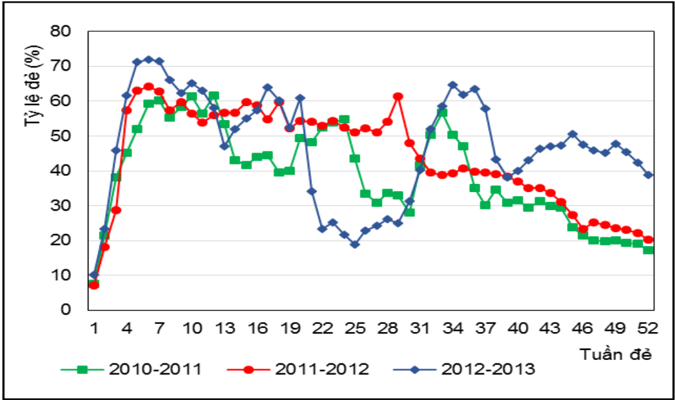

In [7]:
from docling_core.types.doc import PictureItem, TableItem, SectionHeaderItem, ListItem

first_picture = None

for element, _ in conv_res.document.iterate_items():
    if isinstance(element, PictureItem):
        first_picture = element
        break  # dừng lại ngay khi tìm được ảnh đầu tiên

if first_picture:
    print("Kiểu:", type(first_picture).__name__)
    print("Tất cả thuộc tính:")
    for k, v in first_picture.__dict__.items():
        if not k.startswith("_"):
            print(f"  {k}: {v}")
else:
    print("Không tìm thấy PictureItem nào trong tài liệu.")


In [8]:
from docling.chunking import HybridChunker

chunker = HybridChunker()
chunk_iter = chunker.chunk(dl_doc=conv_res.document)

chunks = list(chunk_iter)        # chuyển generator → list
print(len(chunks))    

Token indices sequence length is longer than the specified maximum sequence length for this model (642 > 512). Running this sequence through the model will result in indexing errors


89


In [9]:
from pprint import pprint
pprint((chunks[48]))

DocChunk(text="Nếu vẽ biểu đồ như trong hình 8.2, tác giả đã sử dụng trên cùng một trục tọa độ 2 đơn vị đo khác nhau (số gia súc, số ngày). Không thể vẽ một biểu đồ như vậy, trong trường hợp này, thay cho vẽ biểu đồ hoặc bảng số liệu, chỉ cần diễn tả kết quả bằng đoạn viết sau:\n'Trong số 56 gia súc kiểm tra có 6 con vật bị nhiễm bệnh và phải điều trị trung bình mất 14 ngày mới khỏi'.\n", meta=DocMeta(schema_name='docling_core.transforms.chunker.DocMeta', version='1.0.0', doc_items=[DocItem(self_ref='#/texts/108', parent=RefItem(cref='#/body'), children=[], content_layer=<ContentLayer.BODY: 'body'>, label=<DocItemLabel.TEXT: 'text'>, prov=[ProvenanceItem(page_no=8, bbox=BoundingBox(l=85.104, t=502.54604394531253, r=513.34, b=446.6140439453125, coord_origin=<CoordOrigin.BOTTOMLEFT: 'BOTTOMLEFT'>), charspan=(0, 263))]), DocItem(self_ref='#/texts/109', parent=RefItem(cref='#/body'), children=[], content_layer=<ContentLayer.BODY: 'body'>, label=<DocItemLabel.TEXT: 'text'>, prov=[Provenance

In [20]:
from langchain_chroma import Chroma

vector_store = Chroma(
    collection_name="docs",
    embedding_function=embeddings,
    persist_directory="./chroma_langchain_db",
    # host = "localhost",
    # port = "8000"
)

In [21]:
from langchain_core.documents import Document

def docling_chunks_to_langchain(chunks):
    return [
        Document(
            page_content=chunk.text.strip(),
            metadata=dict(chunk.meta) if chunk.meta else {}  # convert sang dict
        )
        for chunk in chunks
        if chunk.text.strip()
    ]

In [17]:
chunks = docling_chunks_to_langchain(chunks)

AttributeError: 'Document' object has no attribute 'text'

In [22]:
from langchain_core.documents import Document
from uuid import uuid4

def flatten_metadata(metadata):
    """Chuyển tất cả value trong metadata thành str/int/float/bool/None, loại bỏ list/object phức tạp."""
    flat = {}
    for k, v in metadata.items():
        if isinstance(v, (str, int, float, bool)) or v is None:
            flat[k] = v
        else:
            # convert bất kỳ object/tuple/list phức tạp thành string
            flat[k] = str(v)
    return flat

# Chuyển chunks thành Document hợp lệ
docs_serializable = []
for doc in chunks:
    docs_serializable.append(
        Document(
            page_content=getattr(doc, "page_content", getattr(doc, "text", "")),
            metadata=flatten_metadata(getattr(doc, "metadata", {}))
        )
    )

# Tạo UUID
uuids = [str(uuid4()) for _ in range(len(docs_serializable))]

# Push vào ChromaDB
vector_store .add_documents(documents=docs_serializable, ids=uuids)


INFO:httpx:HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"


['d8034437-8fb8-4511-abac-7657497f83ee',
 '476cb498-4453-4c18-85f4-bd7cde873dba',
 '4eac36e3-a2f2-4f7a-ba7e-94637663aa07',
 '06f92d5e-5ca2-490d-a6fd-1c167aae7277',
 '7d2071b6-12f6-461a-8ebf-e11f3dc0139c',
 'db8c2007-9c65-41c1-97a3-3b95e7c73077',
 '1b2784c7-c03d-47d9-87df-c3b3c10e8372',
 'b0850e3c-089c-40cb-881f-68e784285204',
 '4c8c88fd-2785-47d2-9b12-e2537eb7e63e',
 'ca4f7c49-01db-45dc-a74d-4d735aba19b1',
 '0bd05aa1-3e69-45a8-898a-d0d0fd8ac5de',
 '5f9d3d77-7c47-413f-9fca-c90f9087ebcd',
 'acc20d0f-1440-4301-89fc-fc76725fcb12',
 '5f7118a0-0c0b-4fa8-a7f5-80d38de0ed4d',
 'e082cda8-c742-4544-b15d-56ae1f1e0a3f',
 '98ea7f79-421e-48b9-b917-517d7b23facf',
 '885abe75-653e-46f6-b783-f122da408897',
 'a34ca014-f52e-4089-9be5-84f6122e7f34',
 '47c2162b-f45a-40da-885e-908ecf3732c0',
 '17be6344-9b72-4641-bbf2-0b0459ef7bc1',
 '99b4b263-1634-4282-ac50-66edf93b274f',
 '3db2b0f7-dea6-4f44-be31-b166f30cb58d',
 '6202fbcc-23e3-4f6c-aa96-d0c89dbe682f',
 '31b04939-7780-4e65-bf40-0083583a7293',
 '381ebc5a-cbc7-

INFO:httpx:HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"


{'id': '9009805b-449b-4b5e-974c-9befefcca071',
 'metadata': {'doc_items': "[PictureItem(self_ref='#/pictures/1', "
                           "parent=RefItem(cref='#/body'), "
                           "children=[RefItem(cref='#/texts/110'), "
                           "RefItem(cref='#/texts/111'), "
                           "RefItem(cref='#/texts/112'), "
                           "RefItem(cref='#/texts/113'), "
                           "RefItem(cref='#/texts/114'), "
                           "RefItem(cref='#/texts/115'), "
                           "RefItem(cref='#/texts/116'), "
                           "RefItem(cref='#/texts/117'), "
                           "RefItem(cref='#/texts/118'), "
                           "RefItem(cref='#/texts/119'), "
                           "RefItem(cref='#/texts/120'), "
                           "RefItem(cref='#/texts/121'), "
                           "RefItem(cref='#/texts/122'), "
                           "RefItem(cref='#/tex
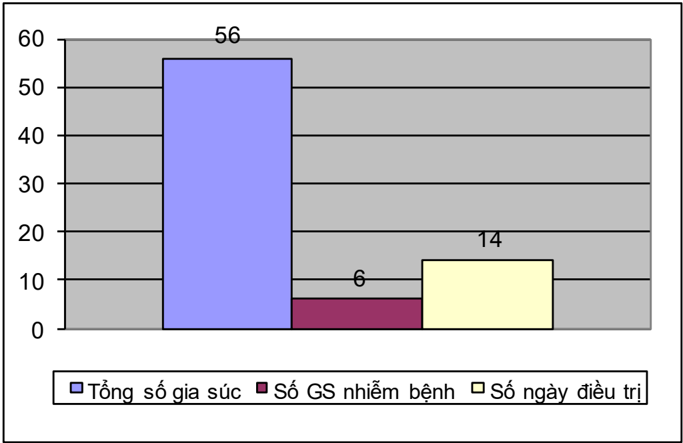

In [25]:
query = "Hãy cho tôi biết về nội dung bảng 8.2: Tình hình nhiễm bệnh và điều trị"
found_docs = vector_store.similarity_search(
    query,
    2)
pprint(found_docs[0].model_dump())  

In [24]:
query = "Với cùng một chỉ tiêu theo dõi, các số thập phân phải làm sao "
found_docs = vector_store.similarity_search(
    query,
    2)
pprint(found_docs[0].model_dump())  

INFO:httpx:HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"


{'id': 'e2420704-ba41-4b7c-b908-11827811b109',
 'metadata': {'doc_items': "[DocItem(self_ref='#/texts/57', "
                           "parent=RefItem(cref='#/groups/11'), children=[], "
                           "content_layer=<ContentLayer.BODY: 'body'>, "
                           "label=<DocItemLabel.LIST_ITEM: 'list_item'>, "
                           'prov=[ProvenanceItem(page_no=6, '
                           'bbox=BoundingBox(l=85.104, t=557.0260439453125, '
                           'r=513.34, b=517.1740439453125, '
                           'coord_origin=<CoordOrigin.BOTTOMLEFT: '
                           "'BOTTOMLEFT'>), charspan=(0, 224))]), "
                           "DocItem(self_ref='#/texts/58', "
                           "parent=RefItem(cref='#/groups/11'), children=[], "
                           "content_layer=<ContentLayer.BODY: 'body'>, "
                           "label=<DocItemLabel.LIST_ITEM: 'list_item'>, "
                           'prov=[Prove